## **Praktikum 07 Dataset college.csv Menggunakan Model Decision Tree**

# Menghubungkan Drive

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
path = "/content/drive/MyDrive/Colab Notebooks/Machine Learning/Praktikum07"

# Mengimpor Library

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Loading Dataset

In [34]:
df = pd.read_csv(path + '/Data/college.csv')
df.head()

,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,male,53900,118,encourage,plan
1,4561,female,24900,87,not encourage,not plan
2,4563,female,65800,93,not encourage,not plan
3,4565,male,11440,117,encourage,plan
4,4567,female,16700,102,not encourage,not plan


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudentID      8000 non-null   int64 
 1   Gender         8000 non-null   object
 2   Parent_income  8000 non-null   int64 
 3   IQ             8000 non-null   int64 
 4   Encourage      8000 non-null   object
 5   Plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB


In [36]:
df.describe()

,StudentID,Parent_income,IQ
count,8000.00000,8000.000000,8000.000000
mean,4000.50000,40584.017500,99.577750
std,2309.54541,18031.506468,18.923655
min,1.00000,4500.000000,60.000000
25%,2000.75000,29400.000000,90.000000
50%,4000.50000,39330.000000,100.000000
75%,6000.25000,51592.500000,110.000000
max,8000.00000,82390.000000,140.000000


In [37]:
df.isnull().sum()

,0
StudentID,0
Gender,0
Parent_income,0
IQ,0
Encourage,0
Plan,0


In [38]:
df = df.rename(columns={
    'StudentID':'id_student',
    'Gender':'gender',
    'Parent_income':'parent_income',
    'IQ':'IQ',
    'Encourage':'encourage',
    'Plan':'plan'
})

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id_student     8000 non-null   int64 
 1   gender         8000 non-null   object
 2   parent_income  8000 non-null   int64 
 3   IQ             8000 non-null   int64 
 4   encourage      8000 non-null   object
 5   plan           8000 non-null   object
dtypes: int64(3), object(3)
memory usage: 375.1+ KB


# Data Understanding (Exploratory Data Analysis)

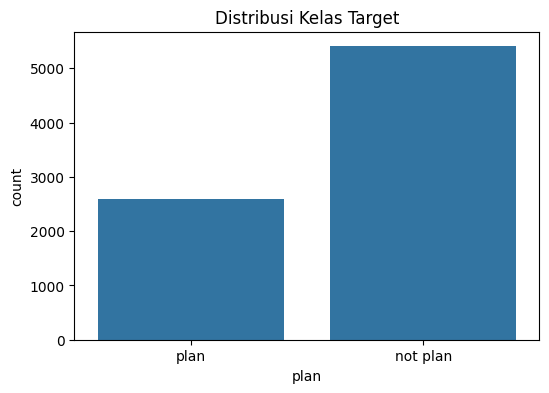

In [40]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=df.columns[-1])
plt.title('Distribusi Kelas Target')
plt.show()

# Analisis Korelasi antar Fitur

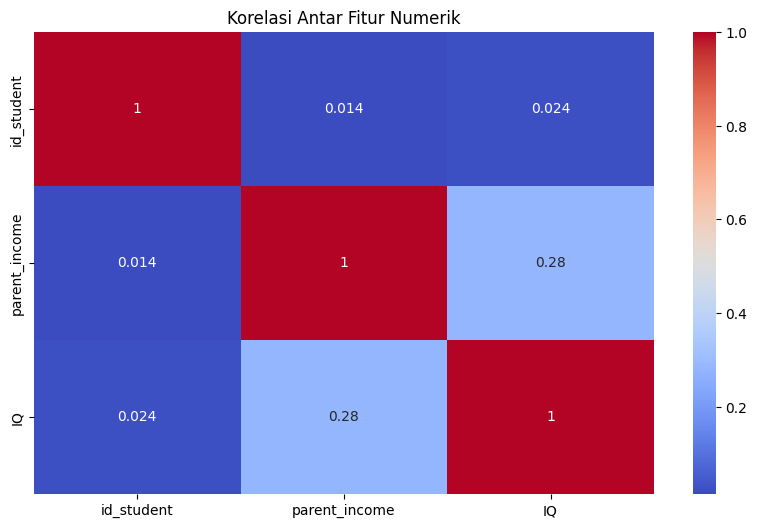

In [41]:
plt.figure(figsize=(10,6))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

# Menentukan Fitur(X) dan Target(y)

In [42]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nisi X:")
print(X.head())
print("\nisi y:")
print(y.head())

X shape: (8000, 5)
y shape: (8000,)

isi X:
   id_student  parent_income   IQ  gender_male  encourage_not encourage
0        4558          53900  118         True                    False
1        4561          24900   87        False                     True
2        4563          65800   93        False                     True
3        4565          11440  117         True                    False
4        4567          16700  102        False                     True

isi y:
0        plan
1    not plan
2    not plan
3        plan
4    not plan
Name: plan, dtype: object


# Pembagian Data Training dan Data Testing

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah total data:", X.shape[0])
print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

print("\nisi X_train:")
print(X_train.head())

print("\nisi y_train:")
print(y_train.head())

Jumlah total data: 8000
Jumlah data training: 6400
Jumlah data testing : 1600

isi X_train:
      id_student  parent_income   IQ  gender_male  encourage_not encourage
270         5075          38070   94         True                    False
7897        7810          68530  119         True                    False
3893        3336          65560  138         True                    False
3938        3419          63810   96         True                    False
5319        2559          40500   88         True                     True

isi y_train:
270     not plan
7897        plan
3893        plan
3938    not plan
5319    not plan
Name: plan, dtype: object


# Pembuatan Model Decision Tree

In [44]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [45]:
y_pred = model.predict(X_test)

print("Akurasi Model Decision Tree:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi Model Decision Tree: 0.826

Confusion Matrix:
 [[960 121]
 [157 362]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

    not plan       0.86      0.89      0.87      1081
        plan       0.75      0.70      0.72       519

    accuracy                           0.83      1600
   macro avg       0.80      0.79      0.80      1600
weighted avg       0.82      0.83      0.82      1600



# Visualisasi Hasil Model Decision Tree

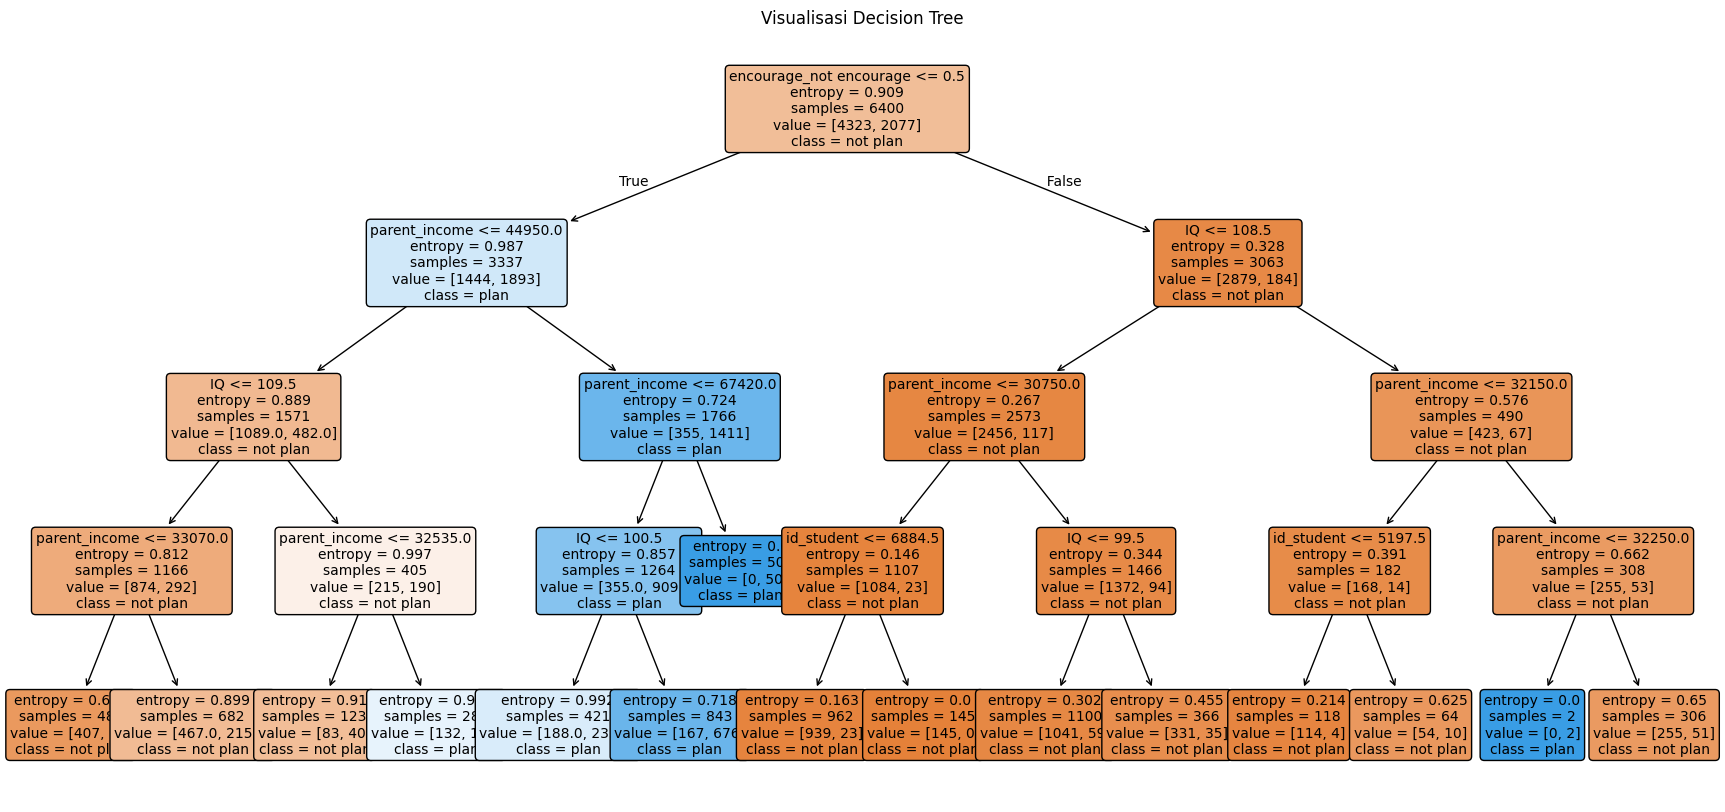

In [46]:
plt.figure(figsize=(22,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visualisasi Decision Tree")
plt.show()

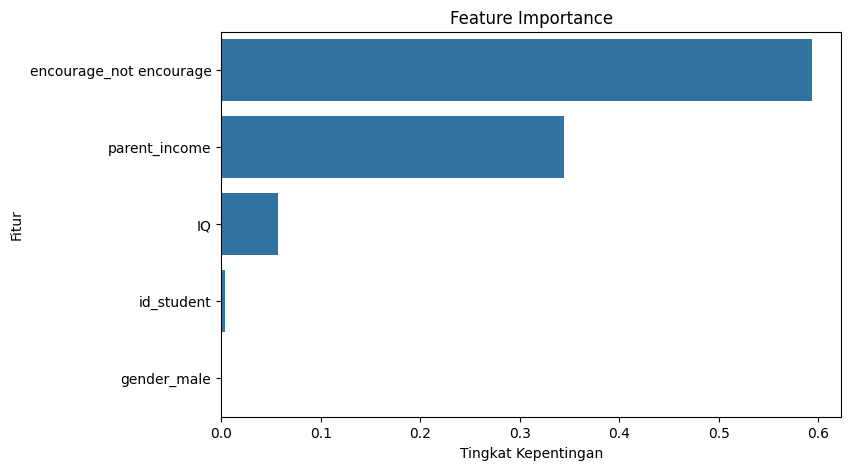

In [47]:
# Fitur yang penting
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance")
plt.xlabel("Tingkat Kepentingan")
plt.ylabel("Fitur")
plt.show()

# Uji Prediksi pada Data Baru

In [48]:
data_baru = pd.DataFrame({
    'age': [22],
    'gpa': [3.8],
    'SAT': [1400]
})

data_baru = pd.get_dummies(data_baru, drop_first=True).reindex(columns=X.columns, fill_value=0)

prediksi_baru = model.predict(data_baru)
print("Prediksi data baru:", prediksi_baru[0])

Prediksi data baru: not plan
